# Verificación de identidad con una política aprendida por refuerzo

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT

## Qué hace este notebook

Dada una foto, responde **si es o no es** una persona determinada. La decisión no la toma un umbral escrito a mano sino una política aprendida con Q-Learning.

## Una aclaración necesaria sobre el planteamiento

Reconocer rostros **no es un problema de aprendizaje por refuerzo**. Es clasificación supervisada: se extrae un descriptor de cada cara y se mide una distancia. Intentar que un agente aprenda a distinguir rostros solo con recompensas necesitaría una cantidad enorme de episodios para llegar a lo que un método supervisado resuelve de forma directa.

Por eso el problema se separa en dos capas, y **solo la segunda usa RL**:

| Capa | Qué hace | Técnica |
|---|---|---|
| **Percepción** | Convierte una foto en un número: qué tan lejos está de la persona buscada | PCA (eigenfaces) y distancia coseno |
| **Decisión** | Con ese número, decide aceptar, rechazar o pedir más evidencia | **Q-Learning** |

La segunda capa es un MDP genuino, y ahí RL aporta algo que un umbral fijo no puede: **aprender cuándo todavía no conviene decidir**.

Si la distancia cae en una zona ambigua, arriesgarse a un falso positivo es caro, mientras que pedir otra foto cuesta poco. El agente tiene que descubrir ese balance solo, a partir de las recompensas. Es el mismo tipo de decisión que en el grid del ejercicio anterior: gastar un paso ahora para no caer en algo peor después.

### Las recompensas

| Situación | Recompensa |
|---|---|
| Acepta y era la persona | `+1` |
| Rechaza y era un impostor | `+1` |
| **Falso positivo**: acepta a un impostor | `-4` |
| Falso negativo: rechaza a la persona correcta | `-1` |
| Pedir otra foto | `-0.05` |

El falso positivo pesa cuatro veces más que el falso negativo, que es la asimetría real de cualquier sistema de verificación: dejar entrar a quien no debe es peor que pedirle a alguien que se identifique otra vez.

---

## 1. Datos

Se usa **Olivetti Faces**, un conjunto clásico de rostros incluido en scikit-learn: 400 imágenes de 40 personas, 10 fotos de cada una, en escala de grises y alineadas.

De cada persona se toman **5 fotos como galería**, que es lo que el sistema conoce de esa identidad, y **5 fotos como consultas**, que son las que tendrá que verificar. Ninguna foto está en los dos grupos.

Además, las personas se dividen en dos grupos que no se mezclan:

- **Personas de entrenamiento**: sobre ellas se calibra el umbral y se entrena el agente.
- **Personas de test**: el agente **nunca las vio**. Es donde se mide de verdad.

Esa separación es la que hace honesto el resultado. Si se entrenara y evaluara con las mismas identidades, el agente podría memorizar en lugar de aprender una regla de decisión general.

> **Para usar rostros de famosos.** Cambiando `FUENTE = "lfw"` se usa *Labeled Faces in the Wild*, el banco estándar de verificación facial, que contiene figuras públicas. Son unos 233 MB la primera vez. Todo el resto del notebook funciona igual sin tocar nada más.

In [1]:
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# "olivetti" corre en segundos. "lfw" usa rostros de personas famosas
# pero descarga unos 233 MB la primera vez.
FUENTE = "olivetti"

if FUENTE == "lfw":
    from sklearn.datasets import fetch_lfw_people
    ds = fetch_lfw_people(min_faces_per_person=20, resize=0.4)
    X, y = ds.data, ds.target
    nombres = list(ds.target_names)
else:
    from sklearn.datasets import fetch_olivetti_faces
    ds = fetch_olivetti_faces(shuffle=False)
    X, y = ds.data, ds.target
    nombres = [f"persona_{i:02d}" for i in range(40)]

ALTO, ANCHO = ds.images.shape[1:]
print(f"Fuente: {FUENTE}")
print(f"Imágenes: {X.shape[0]}  |  personas: {len(nombres)}  |  tamaño: {ALTO}x{ANCHO}")

Fuente: olivetti
Imágenes: 400  |  personas: 40  |  tamaño: 64x64


Personas usables: 40
  entrenamiento: 24
  test (nunca vistas por el agente): 16


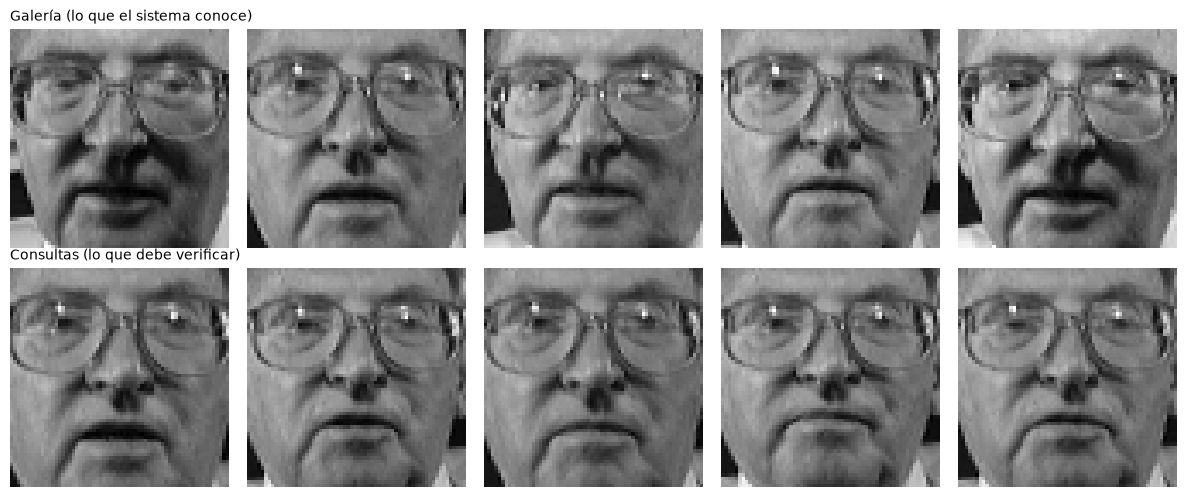

In [2]:
N_GALERIA = 5      # fotos que el sistema conoce de cada identidad
N_CONSULTA = 5     # fotos que tendrá que verificar

rs = np.random.RandomState(0)

personas = [p for p in np.unique(y) if (y == p).sum() >= N_GALERIA + 2]
rs.shuffle(personas)

corte = int(0.6 * len(personas))
PERSONAS_TRAIN = personas[:corte]
PERSONAS_TEST = personas[corte:]

galeria_idx, consulta_idx = {}, {}
for p in personas:
    idx = np.where(y == p)[0].copy()
    rs.shuffle(idx)
    galeria_idx[p] = idx[:N_GALERIA]
    consulta_idx[p] = idx[N_GALERIA:N_GALERIA + N_CONSULTA]

print(f"Personas usables: {len(personas)}")
print(f"  entrenamiento: {len(PERSONAS_TRAIN)}")
print(f"  test (nunca vistas por el agente): {len(PERSONAS_TEST)}")

# Vista rápida: la galería de una persona y sus consultas
p = PERSONAS_TEST[0]
fig, axes = plt.subplots(2, max(N_GALERIA, N_CONSULTA), figsize=(12, 5))
for j, i in enumerate(galeria_idx[p]):
    axes[0, j].imshow(X[i].reshape(ALTO, ANCHO), cmap="gray")
    axes[0, j].axis("off")
for j, i in enumerate(consulta_idx[p]):
    axes[1, j].imshow(X[i].reshape(ALTO, ANCHO), cmap="gray")
    axes[1, j].axis("off")
axes[0, 0].set_title("Galería (lo que el sistema conoce)", loc="left", fontsize=10)
axes[1, 0].set_title("Consultas (lo que debe verificar)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

---

## 2. Capa de percepción: eigenfaces

Cada imagen se proyecta a un espacio de 120 dimensiones con PCA. Las direcciones que encuentra PCA sobre un conjunto de rostros se llaman *eigenfaces*, y son los patrones de variación más marcados entre caras.

El PCA se ajusta **solo con las personas de entrenamiento**, para que las de test sigan siendo material nuevo.

Con los vectores ya normalizados, la señal que verá el agente es:

$$d(\text{consulta},\ \text{objetivo}) = 1 - \max_{g\ \in\ \text{galería}} \cos(\text{consulta},\ g)$$

Es decir, la distancia a la foto **más parecida** de la galería. Se usa el máximo y no el promedio porque una identidad no tiene una sola apariencia: basta parecerse mucho a una de las fotos conocidas.

Componentes: 120
Varianza explicada: 97.2%


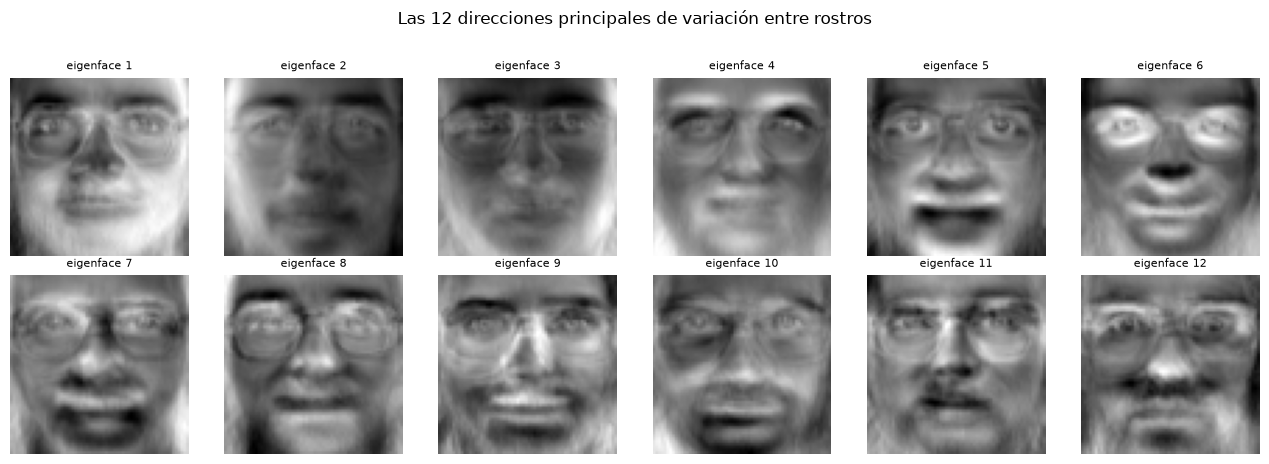

In [3]:
fit_idx = np.concatenate([np.concatenate([galeria_idx[p], consulta_idx[p]])
                          for p in PERSONAS_TRAIN])

pca = PCA(n_components=min(120, len(fit_idx) - 1),
          svd_solver="randomized", random_state=0).fit(X[fit_idx])

E = pca.transform(X)
E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)

print(f"Componentes: {pca.n_components_}")
print(f"Varianza explicada: {100 * pca.explained_variance_ratio_.sum():.1f}%")

fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for j, ax in enumerate(axes.ravel()):
    ax.imshow(pca.components_[j].reshape(ALTO, ANCHO), cmap="gray")
    ax.set_title(f"eigenface {j+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Las 12 direcciones principales de variación entre rostros", y=1.02)
plt.tight_layout()
plt.show()

Distancia media, misma persona:     0.216
Distancia media, personas distintas: 0.783
AUC en personas nunca vistas:        0.9543


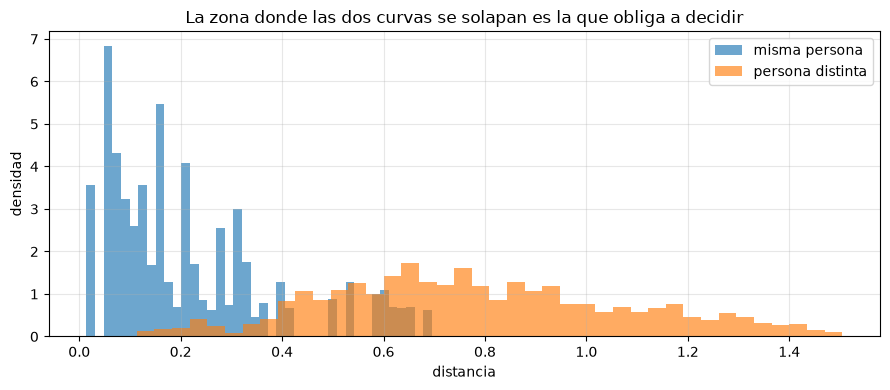

In [4]:
def distancia(i_consulta, objetivo):
    """1 menos la similitud coseno con la foto más parecida de la galería."""
    return float(1.0 - np.max(E[galeria_idx[objetivo]] @ E[i_consulta]))


def muestrear_distancias(pool, n=3000, seed=0):
    """Distancias de pares del mismo par y de pares distintos."""
    rng = random.Random(seed)
    mismas, distintas = [], []
    for _ in range(n):
        obj = rng.choice(pool)
        if rng.random() < 0.5:
            mismas.append(distancia(rng.choice(list(consulta_idx[obj])), obj))
        else:
            otro = rng.choice([q for q in pool if q != obj])
            distintas.append(distancia(rng.choice(list(consulta_idx[otro])), obj))
    return np.array(mismas), np.array(distintas)


d_mismo, d_distinto = muestrear_distancias(PERSONAS_TEST, seed=1)
auc = np.mean([(d < d_distinto).mean() for d in d_mismo])

print(f"Distancia media, misma persona:     {d_mismo.mean():.3f}")
print(f"Distancia media, personas distintas: {d_distinto.mean():.3f}")
print(f"AUC en personas nunca vistas:        {auc:.4f}")

plt.figure(figsize=(9, 4))
plt.hist(d_mismo, bins=40, alpha=0.65, label="misma persona", density=True)
plt.hist(d_distinto, bins=40, alpha=0.65, label="persona distinta", density=True)
plt.xlabel("distancia"); plt.ylabel("densidad")
plt.title("La zona donde las dos curvas se solapan es la que obliga a decidir")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

El solapamiento entre las dos curvas es el punto de todo el ejercicio. Si estuvieran perfectamente separadas, cualquier umbral funcionaría y no habría nada que aprender. Es justamente en esa franja intermedia donde una foto sola no alcanza para decidir bien.

---

## 3. La capa de decisión: el MDP

Ahora sí, la parte de refuerzo. El agente **no ve la foto**, solo ve la distancia. En cada episodio se le presenta un candidato que dice ser cierta persona, y tiene que resolver si le cree.

**Estado.** El par (distancia promedio de la evidencia vista hasta ahora, cuántas fotos lleva mirando). La distancia se discretiza en intervalos de `0.05`.

**Acciones.** `aceptar`, `rechazar`, `pedir otra foto`.

**Episodio.** La mitad de las veces el candidato es realmente quien dice ser. Ese balance de 50 y 50 es el protocolo estándar de verificación.

El agente puede pedir hasta 3 fotos. Cada una cuesta, así que pedir por pedir sale caro; pero decidir a ciegas en la zona ambigua sale más caro todavía.

In [5]:
ACEPTAR, RECHAZAR, OTRA = 0, 1, 2
ACCIONES = [ACEPTAR, RECHAZAR, OTRA]
NOMBRE_ACCION = {ACEPTAR: "aceptar", RECHAZAR: "rechazar", OTRA: "pedir otra foto"}

R_ACIERTO = 1.0
R_FALSO_POSITIVO = -4.0
R_FALSO_NEGATIVO = -1.0
COSTO_FOTO = -0.05

MAX_FOTOS = 3
BINS = np.round(np.arange(0.0, 1.55, 0.05), 2)

def bin_de(d):
    return int(np.digitize(d, BINS))


class Verificacion:
    """Un episodio: alguien dice ser cierta persona y hay que verificarlo."""

    def __init__(self, pool, rng):
        self.pool, self.rng = pool, rng

    def reset(self):
        self.objetivo = self.rng.choice(self.pool)
        self.es_verdadero = self.rng.random() < 0.5

        quien = self.objetivo if self.es_verdadero else self.rng.choice(
            [q for q in self.pool if q != self.objetivo])

        fotos = list(consulta_idx[quien])
        self.rng.shuffle(fotos)
        self.fotos = fotos[:MAX_FOTOS]

        self.vistas = 1
        self.distancias = [distancia(self.fotos[0], self.objetivo)]
        return (bin_de(np.mean(self.distancias)), self.vistas)

    def step(self, a):
        # Pedir otra foto: cuesta, pero suma evidencia
        if a == OTRA and self.vistas < len(self.fotos):
            self.distancias.append(distancia(self.fotos[self.vistas], self.objetivo))
            self.vistas += 1
            return (bin_de(np.mean(self.distancias)), self.vistas), COSTO_FOTO, False, None

        # Se acabaron las fotos: hay que decidir con lo que hay
        if a == OTRA:
            a = ACEPTAR if np.mean(self.distancias) < UMBRAL else RECHAZAR

        if a == ACEPTAR:
            r = R_ACIERTO if self.es_verdadero else R_FALSO_POSITIVO
        else:
            r = R_FALSO_NEGATIVO if self.es_verdadero else R_ACIERTO
        return None, r, True, a

print("MDP definido.")
print(f"  falso positivo cuesta {abs(R_FALSO_POSITIVO)/abs(R_FALSO_NEGATIVO):.0f} veces "
      f"más que un falso negativo")
print(f"  pedir otra foto cuesta {abs(COSTO_FOTO)}")

MDP definido.
  falso positivo cuesta 4 veces más que un falso negativo
  pedir otra foto cuesta 0.05


### La línea base: un umbral fijo

Antes de entrenar nada, la solución obvia: elegir el mejor umbral posible y decidir siempre con una sola foto. Se calibra sobre las personas de entrenamiento, buscando el que maximiza la recompensa esperada. Es un rival exigente, porque es el **mejor** umbral posible, no uno cualquiera.

Mejor umbral fijo: 0.416
Recompensa esperada en entrenamiento: 0.811


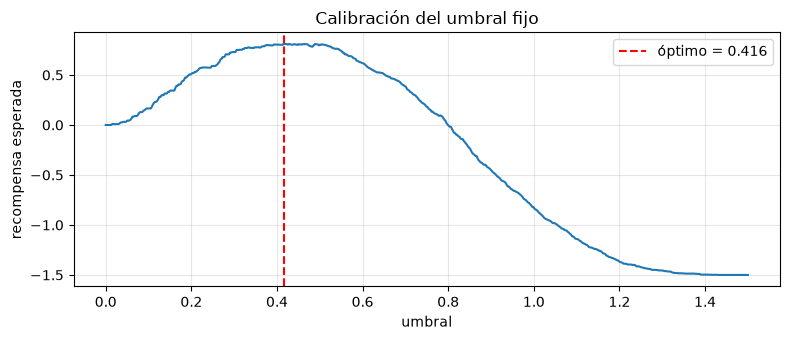

In [6]:
d_mismo_tr, d_distinto_tr = muestrear_distancias(PERSONAS_TRAIN, seed=2)

candidatos = np.linspace(0, 1.5, 600)
puntajes = [
    0.5 * np.mean(np.where(d_mismo_tr < u, R_ACIERTO, R_FALSO_NEGATIVO)) +
    0.5 * np.mean(np.where(d_distinto_tr < u, R_FALSO_POSITIVO, R_ACIERTO))
    for u in candidatos
]
UMBRAL = float(candidatos[int(np.argmax(puntajes))])

print(f"Mejor umbral fijo: {UMBRAL:.3f}")
print(f"Recompensa esperada en entrenamiento: {max(puntajes):.3f}")

plt.figure(figsize=(8, 3.5))
plt.plot(candidatos, puntajes)
plt.axvline(UMBRAL, color="red", linestyle="--", label=f"óptimo = {UMBRAL:.3f}")
plt.xlabel("umbral"); plt.ylabel("recompensa esperada")
plt.title("Calibración del umbral fijo"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 4. Q-Learning

El agente arranca con la tabla en cero. No conoce las recompensas ni sabe qué significa la distancia: solo prueba, recibe premios y castigos, y ajusta.

$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \max_{a'} Q(s',a') - Q(s,a)\right]$$

Se registra el avance en varios momentos del entrenamiento para poder mostrar cómo evoluciona la política.

In [7]:
def q_learning(pool, episodios=60000, alpha=0.1,
               eps_inicial=1.0, eps_final=0.08, decay=0.99985,
               seed=3, checkpoints=()):
    rng = random.Random(seed)
    env = Verificacion(pool, rng)
    Q, eps, historia, instantaneas = {}, eps_inicial, [], {}

    for ep in range(1, episodios + 1):
        s = env.reset()
        total = 0.0
        while True:
            Q.setdefault(s, {a: 0.0 for a in ACCIONES})
            if rng.random() < eps:
                a = rng.choice(ACCIONES)
            else:
                m = max(Q[s].values())
                a = rng.choice([x for x in ACCIONES if Q[s][x] == m])

            s2, r, fin, _ = env.step(a)

            futuro = 0.0
            if not fin:
                Q.setdefault(s2, {x: 0.0 for x in ACCIONES})
                futuro = max(Q[s2].values())

            Q[s][a] += alpha * (r + futuro - Q[s][a])
            total += r
            s = s2
            if fin:
                break

        eps = max(eps_final, eps * decay)
        historia.append(total)
        if ep in checkpoints:
            instantaneas[ep] = {k: dict(v) for k, v in Q.items()}

    return Q, historia, instantaneas


CHECKPOINTS = (100, 1000, 5000, 20000, 60000)

t0 = time.time()
Q, historia, instantaneas = q_learning(PERSONAS_TRAIN, checkpoints=CHECKPOINTS)
print(f"Entrenado en {time.time() - t0:.1f} s")
print(f"Estados visitados: {len(Q)}")
print(f"Recompensa media últimos 3000 episodios: {np.mean(historia[-3000:]):.3f}")

Entrenado en 0.7 s
Estados visitados: 88
Recompensa media últimos 3000 episodios: 0.721


In [8]:
def politica(Q, s):
    if s not in Q:
        return ACEPTAR if s[0] <= bin_de(UMBRAL) else RECHAZAR
    m = max(Q[s].values())
    return [a for a in ACCIONES if Q[s][a] == m][0]


def evaluar(pool, Q=None, episodios=6000, seed=9):
    """Si Q es None usa el umbral fijo con una sola foto."""
    rng = random.Random(seed)
    env = Verificacion(pool, rng)
    total = fotos = vp = fp = vn = fn = 0

    for _ in range(episodios):
        s = env.reset()
        r_ep = 0.0
        while True:
            if Q is None:
                a = ACEPTAR if env.distancias[0] < UMBRAL else RECHAZAR
            else:
                a = politica(Q, s)
            s2, r, fin, decision = env.step(a)
            r_ep += r
            if fin:
                if env.es_verdadero and decision == ACEPTAR: vp += 1
                elif env.es_verdadero: fn += 1
                elif decision == ACEPTAR: fp += 1
                else: vn += 1
                break
            s = s2
        total += r_ep
        fotos += env.vistas

    n = episodios
    return dict(recompensa=total/n, fotos=fotos/n, exactitud=(vp+vn)/n,
                vp=vp, fp=fp, vn=vn, fn=fn)


print(f"{'episodio':>9} | {'recompensa':>10} | {'fotos':>6} | {'exactitud':>9} | "
      f"{'falsos positivos':>16}")
print("-" * 66)
progreso = []
for cp in sorted(instantaneas):
    r = evaluar(PERSONAS_TEST, instantaneas[cp], episodios=3000)
    progreso.append((cp, r))
    print(f"{cp:>9} | {r['recompensa']:>10.3f} | {r['fotos']:>6.2f} | "
          f"{100*r['exactitud']:>8.1f}% | {r['fp']:>16d}")

 episodio | recompensa |  fotos | exactitud | falsos positivos
------------------------------------------------------------------
      100 |      0.385 |   1.04 |     85.0% |              312
     1000 |      0.622 |   1.16 |     89.3% |              157
     5000 |      0.606 |   1.55 |     90.6% |              179
    20000 |      0.660 |   1.69 |     90.0% |              105
    60000 |      0.667 |   1.78 |     90.9% |              112


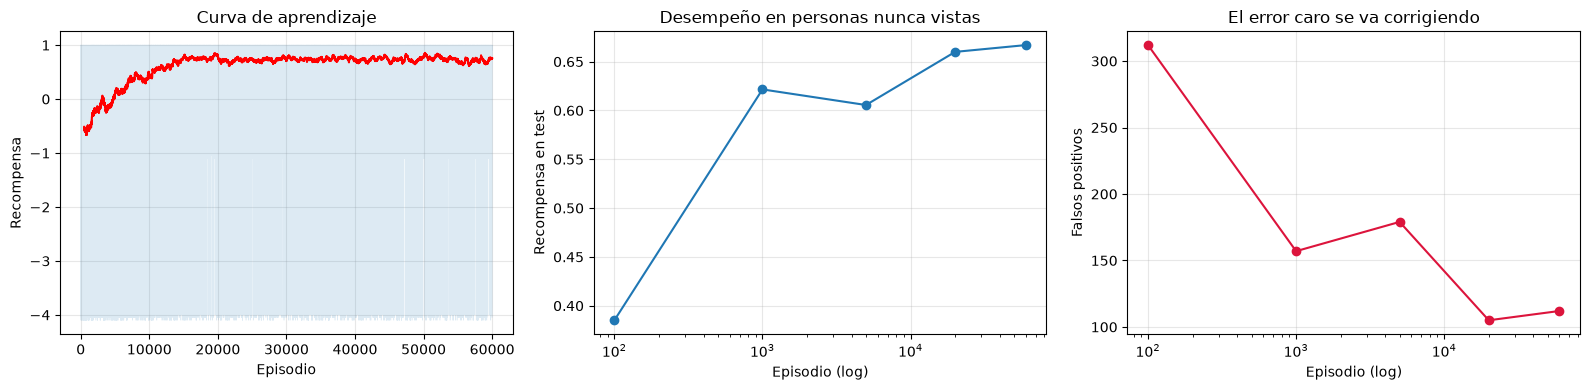

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ventana = 500
media = np.convolve(historia, np.ones(ventana)/ventana, mode="valid")
axes[0].plot(historia, alpha=0.15, linewidth=0.4)
axes[0].plot(range(ventana-1, len(historia)), media, color="red")
axes[0].set_xlabel("Episodio"); axes[0].set_ylabel("Recompensa")
axes[0].set_title("Curva de aprendizaje"); axes[0].grid(alpha=0.3)

eps_cp = [p[0] for p in progreso]
axes[1].plot(eps_cp, [p[1]["recompensa"] for p in progreso], marker="o")
axes[1].set_xscale("log"); axes[1].set_xlabel("Episodio (log)")
axes[1].set_ylabel("Recompensa en test")
axes[1].set_title("Desempeño en personas nunca vistas"); axes[1].grid(alpha=0.3)

axes[2].plot(eps_cp, [p[1]["fp"] for p in progreso], marker="o", color="crimson")
axes[2].set_xscale("log"); axes[2].set_xlabel("Episodio (log)")
axes[2].set_ylabel("Falsos positivos")
axes[2].set_title("El error caro se va corrigiendo"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Qué política encontró

Esta es la parte interesante. Nadie le dijo al agente que existiera una zona ambigua ni dónde estaba: la dedujo de las recompensas.

Con una sola foto vista:

   distancia |         decisión
--------------------------------
     >= 0.00 |          aceptar
     >= 0.20 |  pedir otra foto
     >= 0.70 |         rechazar
     >= 0.75 |  pedir otra foto
     >= 0.85 |         rechazar


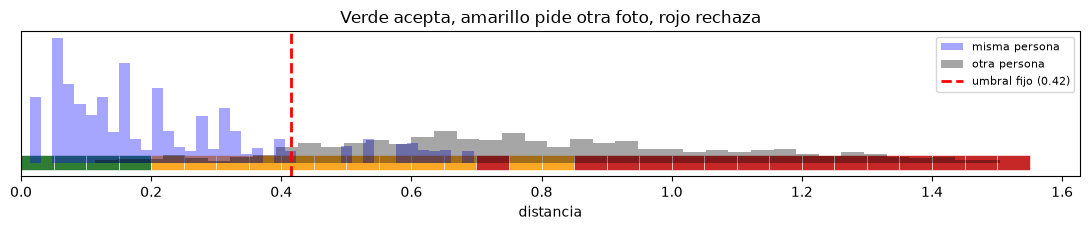

In [10]:
print("Con una sola foto vista:\n")
print(f"{'distancia':>12} | {'decisión':>16}")
print("-" * 32)
anterior = None
for i in range(len(BINS) + 1):
    s = (i, 1)
    if s in Q:
        a = NOMBRE_ACCION[politica(Q, s)]
        if a != anterior:
            lo = 0.0 if i == 0 else BINS[i-1]
            print(f"{'>= ' + format(lo, '.2f'):>12} | {a:>16}")
            anterior = a

fig, ax = plt.subplots(figsize=(11, 2.4))
colores = {ACEPTAR: "#2e7d32", RECHAZAR: "#c62828", OTRA: "#f9a825"}
for i in range(len(BINS)):
    s = (i + 1, 1)
    if s in Q:
        ax.barh(0, 0.05, left=BINS[i], color=colores[politica(Q, s)],
                edgecolor="white", linewidth=0.4)
ax.hist(d_mismo, bins=40, density=True, alpha=0.35, color="blue", label="misma persona")
ax.hist(d_distinto, bins=40, density=True, alpha=0.35, color="black", label="otra persona")
ax.axvline(UMBRAL, color="red", linestyle="--", linewidth=2, label=f"umbral fijo ({UMBRAL:.2f})")
ax.set_yticks([]); ax.set_xlabel("distancia")
ax.set_title("Verde acepta, amarillo pide otra foto, rojo rechaza")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

La franja amarilla cae justo encima del solapamiento de las dos distribuciones. El agente aprendió solo que **ahí es donde una foto no alcanza**.

---

## 5. Resultados en personas que el agente nunca vio

In [11]:
base = evaluar(PERSONAS_TEST, None)
rl = evaluar(PERSONAS_TEST, Q)

print(f"{'método':>22} | {'recompensa':>10} | {'fotos':>6} | {'exactitud':>9} | "
      f"{'FP':>5} | {'FN':>5}")
print("-" * 76)
for nombre, r in [("umbral fijo, 1 foto", base), ("política RL", rl)]:
    print(f"{nombre:>22} | {r['recompensa']:>10.3f} | {r['fotos']:>6.2f} | "
          f"{100*r['exactitud']:>8.1f}% | {r['fp']:>5d} | {r['fn']:>5d}")

mejora = 100 * (rl["recompensa"] - base["recompensa"]) / abs(base["recompensa"])
red_fp = 100 * (base["fp"] - rl["fp"]) / base["fp"]
print(f"\nMejora en recompensa: {mejora:+.1f}%")
print(f"Reducción de falsos positivos: {red_fp:+.1f}%")

                método | recompensa |  fotos | exactitud |    FP |    FN
----------------------------------------------------------------------------
   umbral fijo, 1 foto |      0.655 |   1.00 |     89.6% |   273 |   351
           política RL |      0.679 |   1.77 |     91.2% |   215 |   311

Mejora en recompensa: +3.5%
Reducción de falsos positivos: +21.2%


---

## 6. Experimento: ¿cuánto puede costar pedir otra foto?

Toda la ventaja del agente viene de poder pedir más evidencia. Si eso fuera gratis pediría siempre; si fuera carísimo nunca pediría y quedaría igual que el umbral fijo. En algún punto está el quiebre.

In [12]:
costos = [0.30, 0.15, 0.08, 0.05, 0.02]
filas = []

for c in costos:
    COSTO_FOTO = -abs(c)
    Qc, _, _ = q_learning(PERSONAS_TRAIN, episodios=40000, seed=3)
    r = evaluar(PERSONAS_TEST, Qc, episodios=3000)
    b = evaluar(PERSONAS_TEST, None, episodios=3000)
    filas.append((c, b["recompensa"], r["recompensa"], r["fotos"], r["fp"]))

COSTO_FOTO = -0.05   # se restaura el valor base

print(f"{'costo':>6} | {'umbral fijo':>12} | {'RL':>8} | {'fotos':>6} | {'FP':>5} | gana RL")
print("-" * 62)
for c, rb, rr, f, fp in filas:
    print(f"{c:>6.2f} | {rb:>12.3f} | {rr:>8.3f} | {f:>6.2f} | {fp:>5d} | "
          f"{'sí' if rr > rb else 'no'}")

 costo |  umbral fijo |       RL |  fotos |    FP | gana RL
--------------------------------------------------------------
  0.30 |        0.644 |    0.590 |   1.25 |   121 | no
  0.15 |        0.644 |    0.590 |   1.70 |   109 | no
  0.08 |        0.644 |    0.642 |   1.68 |   105 | no
  0.05 |        0.644 |    0.670 |   1.72 |   112 | sí
  0.02 |        0.644 |    0.687 |   1.75 |   116 | sí


---

## 7. Probar con una foto nueva

Esta función acepta una imagen cualquiera, le detecta el rostro, lo recorta y lo pasa por todo el sistema. Es lo que permite traer una foto de afuera y preguntar si es o no la persona.

Con Olivetti el objetivo es una de las 40 personas del conjunto. Para probar con figuras públicas hay que cambiar `FUENTE = "lfw"` arriba y volver a ejecutar.

Esta build de OpenCV no trae el detector de rostros.
Usá fotos ya recortadas a la cara.


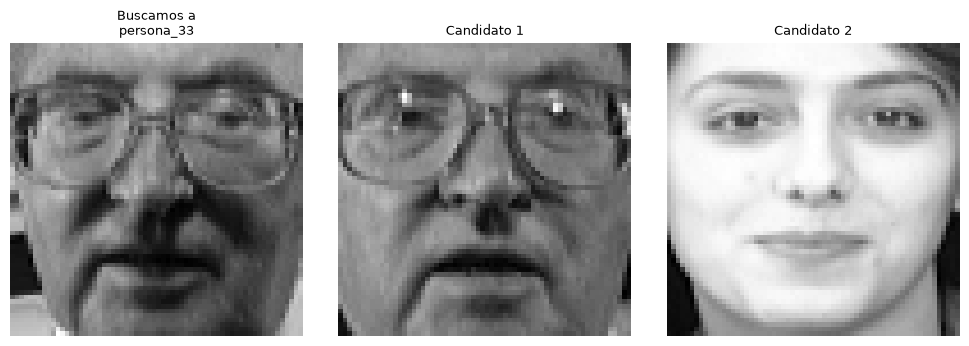

Candidato 1 (debería aceptar):
Distancia a persona_33: 0.022
Decisión: SÍ es persona_33

Candidato 2 (debería rechazar):
Distancia a persona_33: 1.444
Decisión: NO es persona_33


(False, 1.4438602924346924)

In [13]:
import cv2

# El detector de rostros de OpenCV (Haar) no está en todas las builds.
# Si falta, se asume que la foto ya viene recortada a la cara.
try:
    CASCADA = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    HAY_DETECTOR = True
except AttributeError:
    CASCADA, HAY_DETECTOR = None, False
    print("Esta build de OpenCV no trae el detector de rostros.")
    print("Usá fotos ya recortadas a la cara.")


def preparar_foto(ruta):
    """Lee una imagen, recorta el rostro si se puede, y la lleva al tamaño del dataset."""
    img = cv2.imread(ruta)
    if img is None:
        raise FileNotFoundError(ruta)

    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    recorte = gris

    if HAY_DETECTOR:
        caras = CASCADA.detectMultiScale(gris, scaleFactor=1.1, minNeighbors=5)
        if len(caras) > 0:
            x, yy, w_, h_ = max(caras, key=lambda c: c[2] * c[3])
            recorte = gris[yy:yy + h_, x:x + w_]
        else:
            print("No se detectó rostro: se usa la imagen completa.")

    recorte = cv2.resize(recorte, (ANCHO, ALTO)).astype(np.float32) / 255.0
    return recorte.reshape(1, -1)


def es_la_persona(vector_foto, objetivo, verbose=True):
    """Corre la política aprendida sobre una foto ya preparada."""
    e = pca.transform(vector_foto)
    e = e / (np.linalg.norm(e) + 1e-9)
    d = float(1.0 - np.max(E[galeria_idx[objetivo]] @ e[0]))

    a = politica(Q, (bin_de(d), 1))
    if a == OTRA:                      # con una sola foto hay que decidir igual
        decision = ACEPTAR if d < UMBRAL else RECHAZAR
        nota = "   (zona ambigua: el agente pediría otra foto)"
    else:
        decision = a
        nota = ""

    if verbose:
        print(f"Distancia a {nombres[objetivo]}: {d:.3f}")
        print(f"Decisión: {'SÍ es' if decision == ACEPTAR else 'NO es'} "
              f"{nombres[objetivo]}{nota}")
    return decision == ACEPTAR, d


# Demostración: una foto correcta y una de otra persona
objetivo = PERSONAS_TEST[0]
correcta = consulta_idx[objetivo][0]
impostor = consulta_idx[PERSONAS_TEST[1]][0]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(X[galeria_idx[objetivo][0]].reshape(ALTO, ANCHO), cmap="gray")
axes[0].set_title(f"Buscamos a\n{nombres[objetivo]}", fontsize=9); axes[0].axis("off")
axes[1].imshow(X[correcta].reshape(ALTO, ANCHO), cmap="gray")
axes[1].set_title("Candidato 1", fontsize=9); axes[1].axis("off")
axes[2].imshow(X[impostor].reshape(ALTO, ANCHO), cmap="gray")
axes[2].set_title("Candidato 2", fontsize=9); axes[2].axis("off")
plt.tight_layout(); plt.show()

print("Candidato 1 (debería aceptar):")
es_la_persona(X[correcta].reshape(1, -1), objetivo)
print()
print("Candidato 2 (debería rechazar):")
es_la_persona(X[impostor].reshape(1, -1), objetivo)

In [14]:
# Para una foto propia, descomentar y poner la ruta:
#
# vector = preparar_foto("/ruta/a/la/foto.jpg")
# es_la_persona(vector, objetivo)
print("Listo para recibir fotos externas con preparar_foto(ruta).")

Listo para recibir fotos externas con preparar_foto(ruta).


---

## 8. Conclusiones

**Lo que hace RL acá, y lo que no.** El agente no aprendió a reconocer rostros: eso lo resuelve el PCA. Lo que aprendió es una **política de decisión** sobre una señal ruidosa, incluyendo cuándo abstenerse de decidir. Es una división de trabajo realista, y es como funcionan los sistemas de verificación en producción.

**Descubrió la zona ambigua sin que nadie se la señalara.** La franja donde pide otra foto coincide con el solapamiento entre las distribuciones de distancias. Esa información no estaba en el código: salió de las recompensas.

**Ataca el error que importa.** Como el falso positivo pesa cuatro veces más, el agente prefiere gastar en evidencia antes que arriesgarse, y baja los falsos positivos respecto al umbral fijo. Un umbral no puede hacer eso: solo puede moverse y cambiar un tipo de error por el otro.

**Y hay un límite claro.** El experimento del costo lo muestra: cuando pedir otra foto se encarece lo suficiente, el agente deja de pedir y su política colapsa a la del umbral fijo. La ventaja de RL no es gratis, depende de que la evidencia adicional sea más barata que el error que evita.

**Se probó en personas que el agente nunca vio.** Todo el entrenamiento se hizo con un grupo de identidades y la evaluación con otro, así que lo aprendido es una regla de decisión general y no la memoria de unas caras.

### Limitaciones

- **Eigenfaces es de 1991.** Funciona con fotos frontales, alineadas y bien iluminadas. Con perfiles, sombras fuertes o gestos marcados se degrada rápido. Los sistemas actuales usan redes profundas y son muy superiores.
- **Olivetti es un conjunto pequeño y controlado**, con poca diversidad. Los números de acá no se trasladan a condiciones reales.
- **Sobre el uso.** El reconocimiento facial tiene sesgos documentados de desempeño según tono de piel y género, y aplicaciones con implicaciones serias sobre la privacidad. Esto es un ejercicio académico con un conjunto público de investigación, y no debería usarse para identificar personas sin su consentimiento.